Historical Gaelic Transformer Correction and OCR

By Joseph "Joby" Read

The motivation for this project was inspired by the data cleaning we did in class to establish a ground truth, and it explores whether training fine-tuned models is preferable to correcting the outputs of more general or commercial models.

This project is a pipeline of a transformer encoder-decoder model supported by a post-OCR correction via an encoder-decoder BART model. This project also runs a page pre-processing, line-by-line cropping, and normalized ground truth assignment to the cleaned and cropped text image lines. Second, fine-tuning TrOCR (Microsoft’s printed model, Li et al., 2022) with PyTorch. This was chosen because TrOCR studies show fine-tuned models can compete with Transkribus models for accuracy (Ströbel et al., 2022). Third, tuning a BART correction model specifically for old Irish texts, using our ground truth (Dereza, Ni Chonghaile, and Wolf 2024, accessed from Hugging Face repository of user ancatmara). All of the model's steps are evaluated and compared to Tesseract’s Irish Gaelic and Latin trained models combined, as well as Transkribus An Gaodhal character error rate of 1.4% (Dereza, Ni Chonghaile, and Wolf 2024). 

Background and Literature review:

In Li et al., 2022, TrOCR was determined to be more effective at transferred learning due to its encoder-decoder structure, especially in the case of Latin-based scripts. Older OCR models typically use CNN and RNN for feature extraction and character decoding. The TrOCR is simpler in design and has competitive results compared to the older methods, according to the study. This is why transformer-based OCR was chosen for this study for its simplicity and effectiveness (Li et al., 2022). 

Additionally, in Ströbel et al., 2022, TrOCR was determined to be similar in competitiveness to Transkribus in OCR for handwritten Latin. Transkribus also has a model specifically trained on Cló Gaelic characters used in modern Irish and English text (Dereza, Ni Chonghaile, and Wolf 2024). These studies provide the basis that this project has the potential to produce TrOCR outputs that can rival top-of-the-line models, despite its simpler design (Li et al., 2022, and Ströbel et al., 2022). 

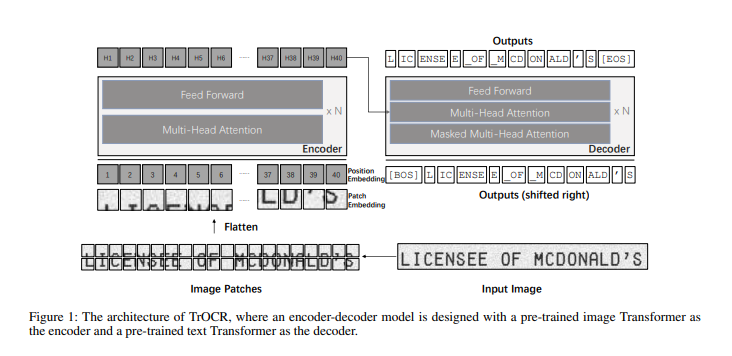


Figure 1 (from Li et al., 2022) shows conceptually how TrOCR works. Cropped lines are split into patches, flattened, and then passed through the encoder, which learns the shapes, strokes, and spacing. This visual information is then fed into the decoder, which generates corresponding text.

BART is also an encoder-decoder model, similar to TrOCR, but it uses text-to-text corrections rather than image-to-text OCR. BART was used by Lewis et al., 2020 for OCR denoising, and trained the model by taking a custom token scheme for their data, adding noise to their text, and training the model on the ground truth to establish the model. Because BART is text-to-text, it can provide insight into patterns for correction and has also been used in literature as a translation model (Lewis et al., 2020; Soper et al., 2021). This allows BART to correct patterns of failure in OCR processes, and is an excellent case for study.

In “To Have the ‘Million’ Readers Yet”: Building a Digitally Enhanced Edition of the Bilingual Irish-English Newspaper an Gaodhal (1881-1898) (Dereza et al., LT4HALA 2024), they used BART training on their first Transkribus run, which had a character error rate of 3.47% and a word error rate of 11.92%. The results of their BART correction were 3.65% and a word error rate of 10.37%. This BART model was taken from Hugging Face, hosted by the user ancatmara, and used for post-OCR correction of Tesseract, combined Irish Gaelic and Latin trained OCR models for version 4+ of Tesseract. This BART model was used because Cló Gaelic characters were used in writing the newspaper, even though the paper was written in bilingual modern Irish Gaelic and English. The tokenization of the BART model was customized to their project, including the tokenization, and may be a source of error. Training a custom BART model is outside the scope of this project and should be considered for future work.

Methods:

To prepare the pages for segmentation, cropping, and assignment, this project performs standard image processing operations, including denoising, page-level skew corrections, alignment correction, image binarization, and segment-level height adjustment to maximize usable samples. Line crops are then produced from a projection profile segmentation custom method. OCR needs exact crops to avoid confusing the training process, and a larger corpus is needed for reliable results.

Rejected pages were iteratively re-evaluated in 3 refinement passes using different segmentation thresholds and rule-based crop repair. The rules used to determine the crop legitimacy were the crop line to GT line count, whether the crops contained low amounts of ink, structural noise, and whether the crops were overlapping or overestimated. The refinement passes involved adjustments to crop height, finding gaps in between segments that indicated unassigned lines, splitting merged lines, removing overcounted lines, and removing structural noise. The final result was 702 accepted pages, of which 443 lines were rejected, leaving 26,975 paired lines for TrOCR training. This was then normalized by removing repeated spaces and converting breaks into single spaces before training and evaluation.

For model evaluation, Tesseract 5 and the combined modern Gaelic and Latin models were used to establish a testable baseline of OCR correction and comparison to our fine-tuned TrOCR model performance, as well as evaluate BART performance correction on more generalized models. Also, the Transkribus An Gaodhal model character error rate was used as a comparison benchmark of 1.4% CER.

The BART model was initiated from a pretrained Hugging Face checkpoint, “ancatmara/bart-ocr-correction-ga-en”, with An Gaodhal-specific tokens that were unaltered. The TrOCR model, Microsoft's “microsoft/trocr-base-printed”, was also initialized from a pre-trained checkpoint accessed through Hugging Face.

The training split for the TrOCR models is 18,914 training, 4,056 testing, and 4,005 lines for validation. The training split for the Tesseract BART model is significantly higher because Tesseract only rejected 5 lines, leaving 27,413 lines, which were split via 19,202 training, 4,138 testing, and 4,073 lines for validation.

To keep our fine-tuned models comparable, all the fine-tuned models use an initial learning rate of 5e-5 with a cosine learning-rate schedule. The cosine scheduler was chosen because the models will learn more quickly and reduce their learning over time to avoid model learning instability (Loshchilov and Hutter, 2017). For similar reasons the TrOCR model also used a 10% warmup step to increase the learning rate at the start, this has been shown in literature to reduce early learning instability (Xiong et al,. 2020; Kalra and Barkeshli, 2024). All the models fine-tuned in this study used AdamW as their learning optimizer, and it was the default for the models we chose to fine-tune. The TrOCR was run for 12 epochs, with the best result kept for BART refinement comparison. Two BART models were trained on the TrOCR model and Tesseract’s combined gle + lat model outputs. Each BART model ran for 6 epochs, with the best result kept for comparison. The fine-tune runs were run in batches of 32 paired samples to utilize available GPU memory on the servers. The experiments were conducted on 2x NVIDIA RTX PRO 6000 Blackwell servers to compare training times. 

Data:

This study’s primary data set was a collection of scanned Historical Irish law documents printed in Cló Gaelic script. The ground truth data was constructed by classmates and verified by Michael Wolf, our professor. This corpus contains 785 raw TIFF scans of individual pages, 811 hand-corrected ground-truth pages; of these pages, 784 of them had matching pairs. After preprocessing, cropping, and vetting, 702 paired GT and pages were established for training with 26,975 trainable paired lines for OCR and 27,413 lines for Tesseract.

Results:

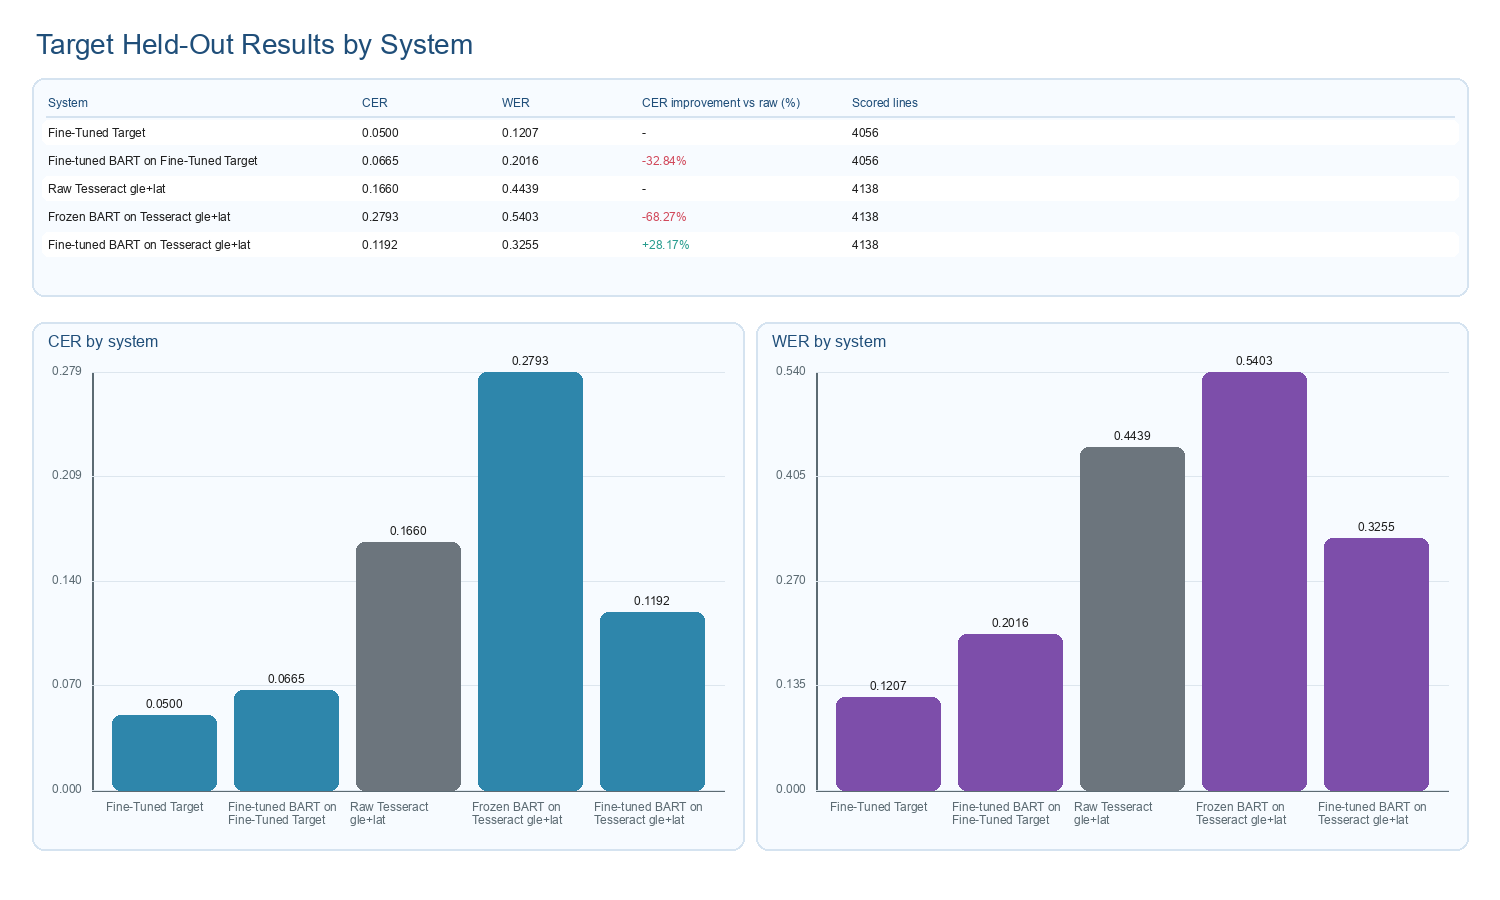

TrOCR performed the strongest with a tested CER of 5%. The Raw un-altered results of Tesseract gle+lat was much worse at 16.6% CER. BART fine tuned to Tesseract had a performance gain of 28.19% in character error rate reduction and a 26.67% reduction in word error rate, showing validity in An Gaodhal trained BART being used for correction on less accurate OCR models. However, BART increased the TrOCR error rate by 33% post correction. This shows that fine tuning a TrOCR model produces much more accurate results and BART is possibly much more useful in correcting noisy OCR models. Reflected in Dereza et al.(LT4HALA 2024), where BART correction produced only mixed gains on an already strong Transkribus model: CER changed from 3.47% to 3.65%, while WER marginally improved from 11.92% to 10.37%. This would need to be studied further though to justify a full claim of irrelevancy to finely tuned models, but these results suggest its benefits depend on the quality of the corrected OCR model.

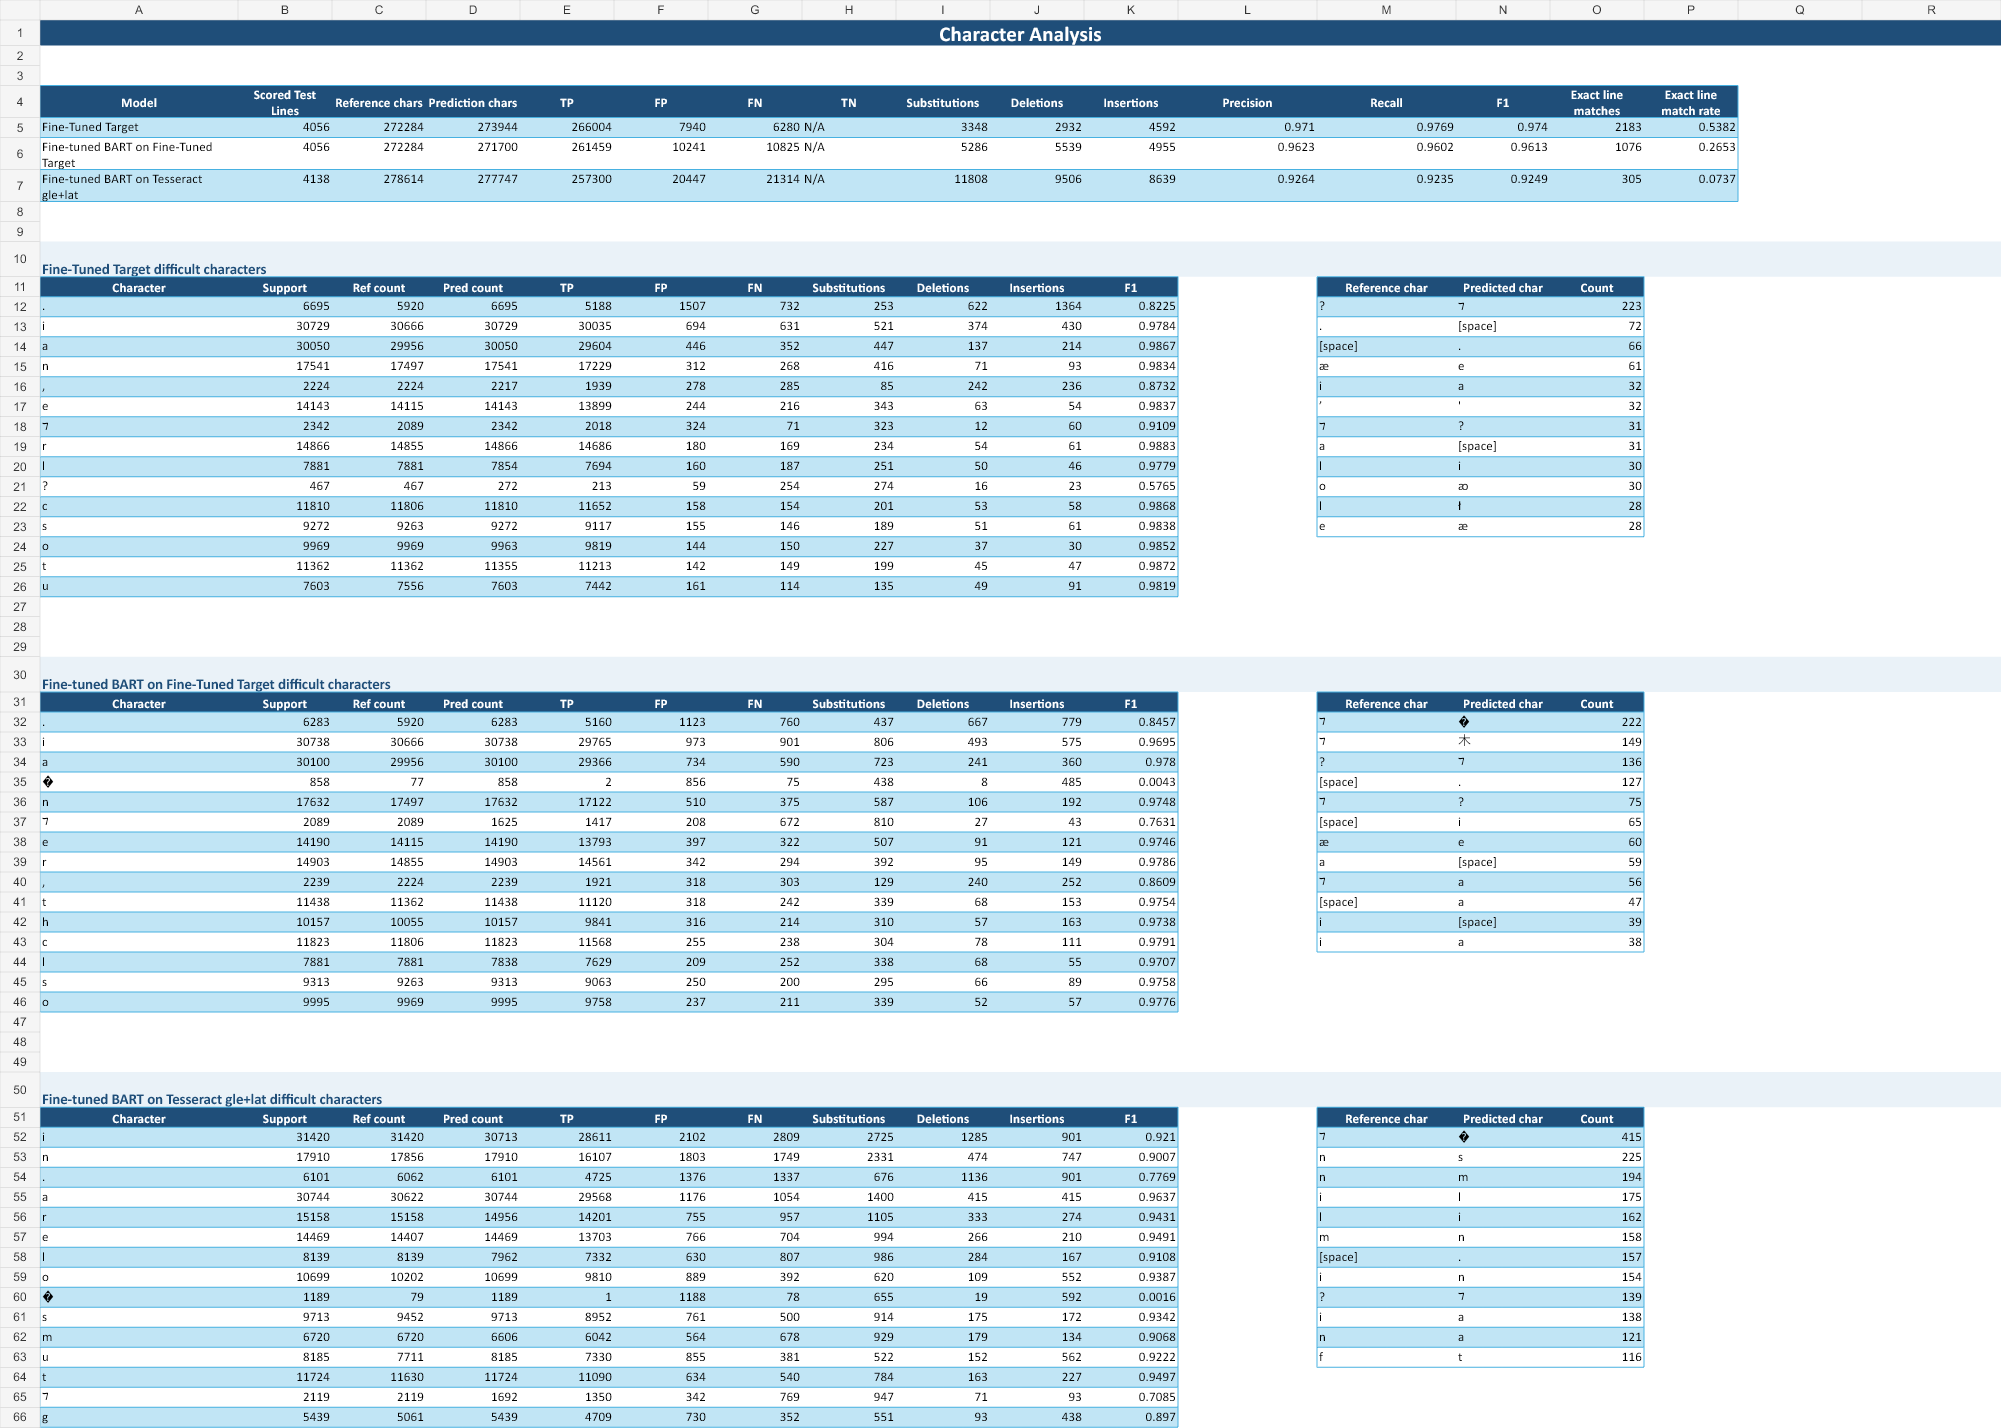

For character error rates it becomes even more clear that TrOCR does much better than our tuned BART correction, the tironian symbol is classified as an unknown character, this could have to do with the tokens which it was trained on and could be improved if the tokens were corpus specific.
Interestingly the question mark is often confused with the tironian and is a persistent error across all methods, this could be a topic of future work. Periods and punctuation marks struggle heavily in all models and more advanced methods and or refinement than explored in this study would be needed to fix the missatributions of the unique roman numeral markings in the text, .x. for example seems to be difficult to pick up using this studies simple transformer methods.

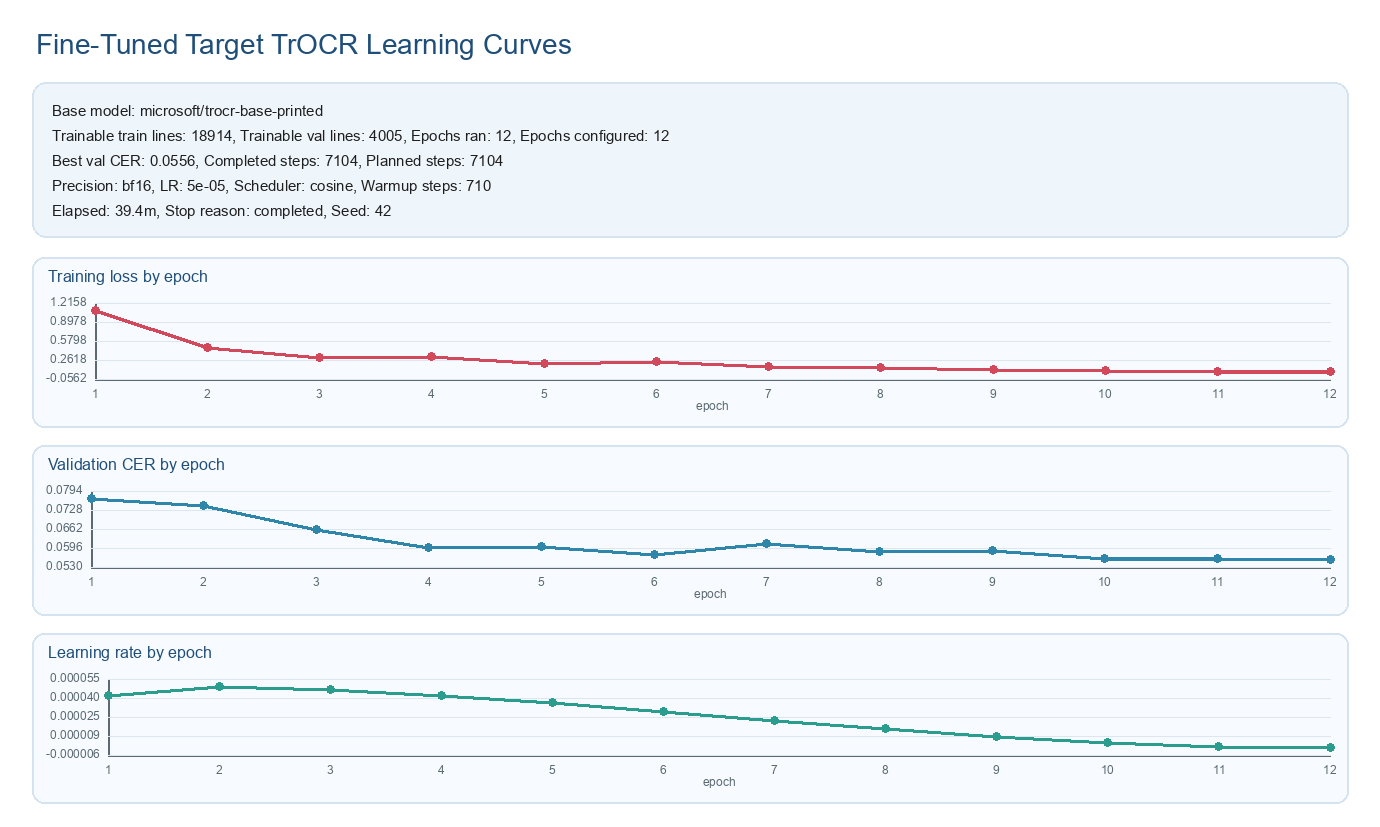


TrOCR had the longest training time with almost 40 minutes of run time for 12 epochs. Though the training graph seems a little wavy it maintains a sloped descent and maintained a validation score of 5.56% which indicates it does okay at generalizing OCR beyond its training data, making it the strongest result of this study.

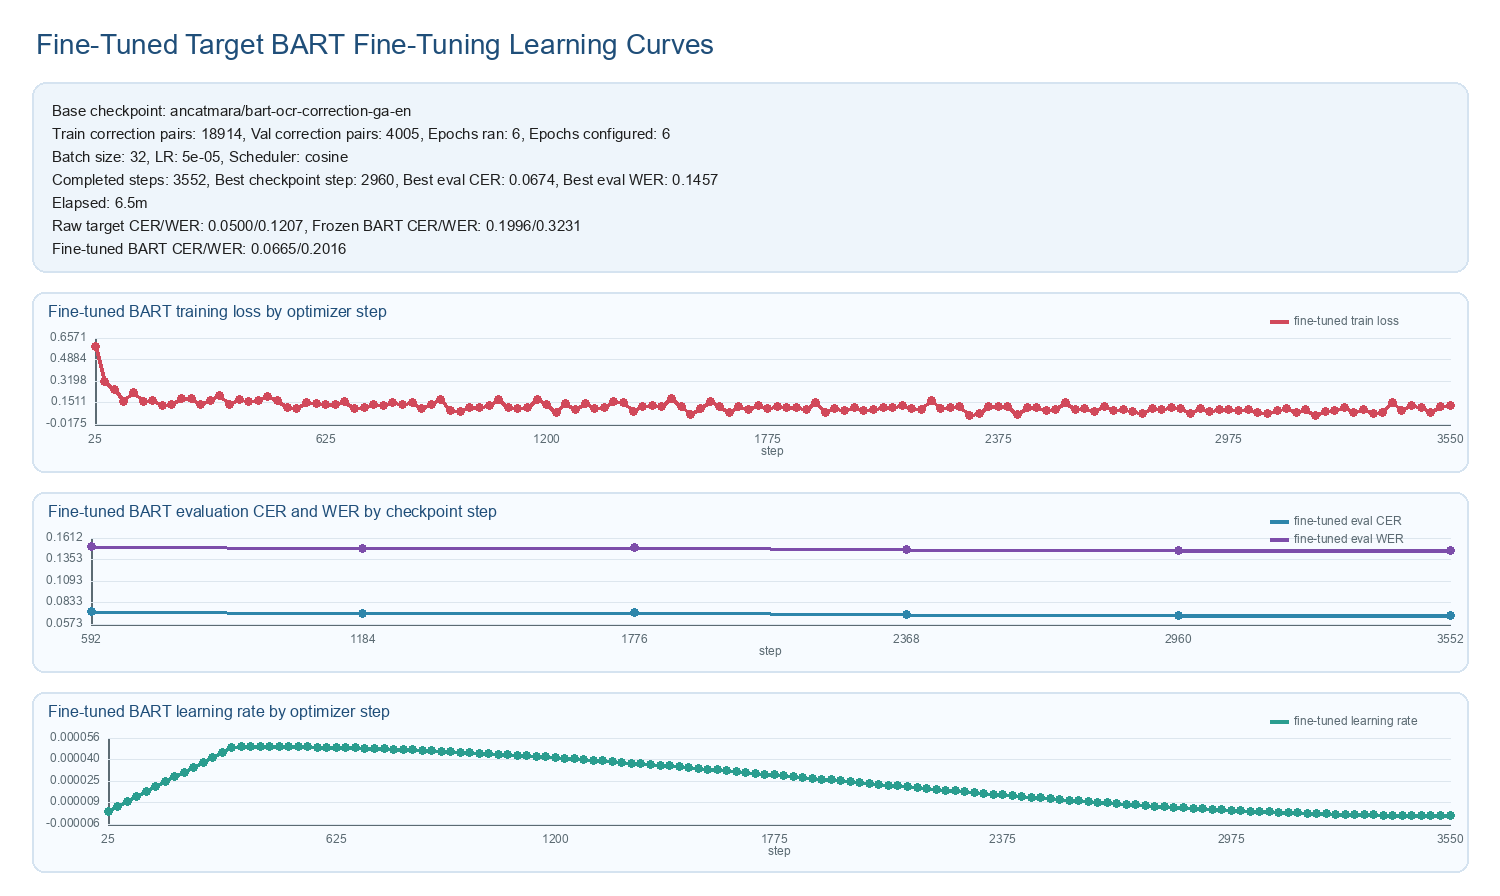

The fine-tuned bart run has the most telling unstable descent, this indicates that BART correction in this method is unstable, even with the cosine scheduler.

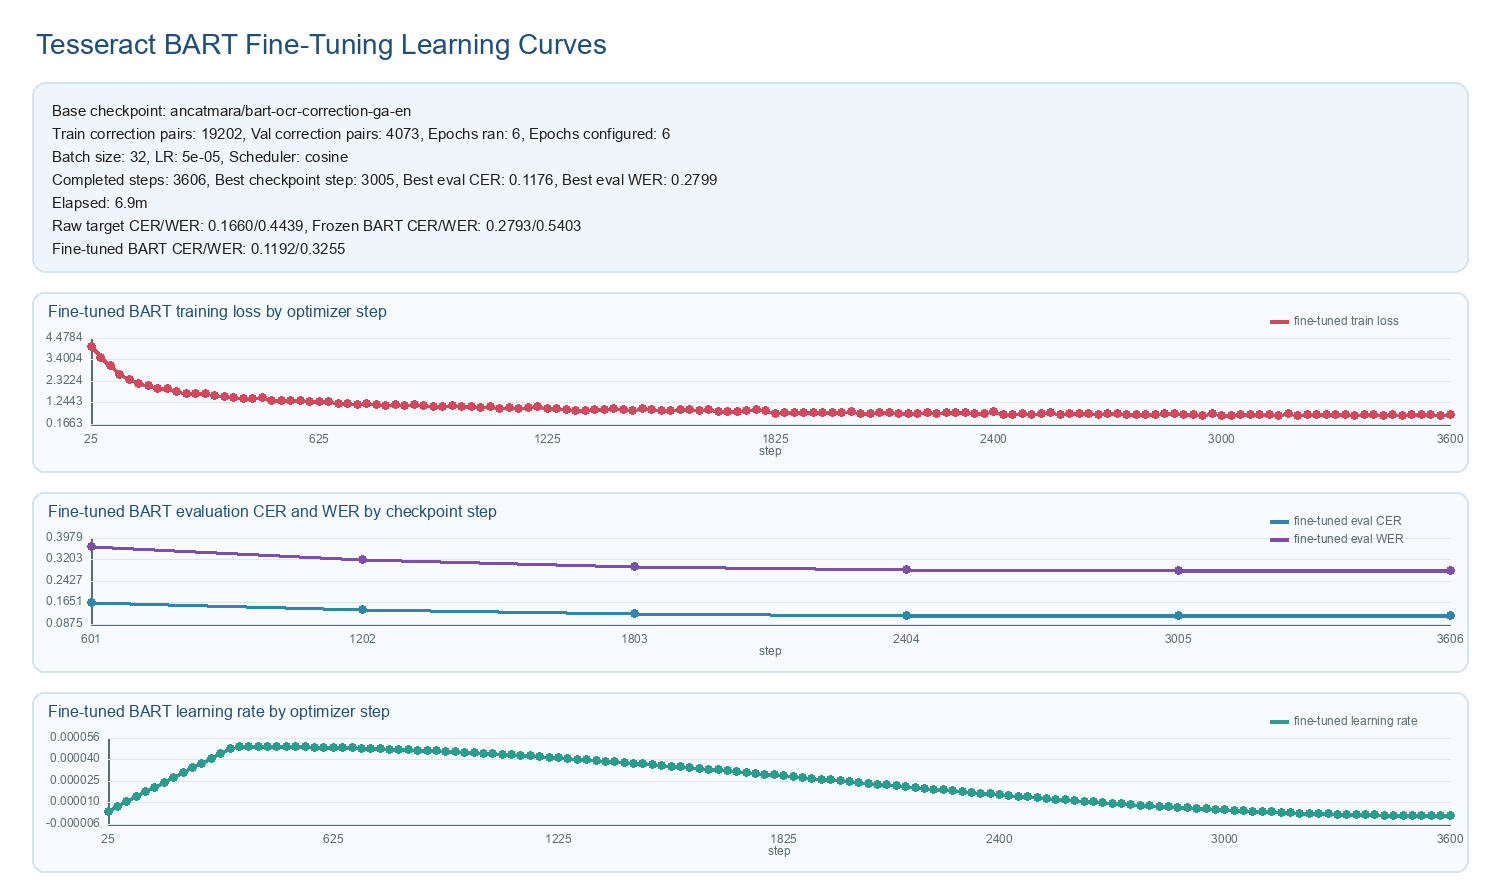

The BART Tesseract correction training graph is perhaps the smoothest of the graphs with an excellent descent indicating that it is a good possible correction method, but swapping out the An Gaodhal tokens for a domain specific tokenizer could lead to better results.

Conclusions:

This study shows that corpus-specific OCR fine-tuning was more effective at transferred learning to a specific data set than BART models. Additionally, after segmentation, TrOCR is less demanding of a technique of transcribing images of text, as compared to BART which may need domain specific tokens compatible with BART to achieve best results. The TrOCR clearly outperforms the Tesseract baseline, even with improvements via an applicable BART model. BART corrections are not fully transferable nor reliable in correcting fine tuned OCR models. This study therefore suggests that historical Gaelic OCR should have more effort put into creating custom models rather than using general models and correcting their outputs. Further, based on finding, this paper supports the use of fine tuned transformer OCR as a viable approach to our training corpus, while highlighting the effectiveness of post OCR correction depends on the quality of the OCR model. 

Future work and considerations:

For our BART model, creating a custom token set for our data and using a transfer learning approach to the An Gaodhal BART model, and then fine-tuning it would be optimal for the use of BART for this experiment in the future, as it could lead to better results on more poorly performing models. 

For the TrOCR model, more experimentation with epochs and fine-tuning could lead to better results.

Other models have shown great success in OCR methods; Transkribus still has a better model than what this project has managed to create. 

Machine learning segmentation processes tend to have a higher recovery rate than the methods used in this study and should be strongly considered for future work.

AI-Assisted Workflow and Human Oversight:

I used AI tools (ChatGPT/Codex) with permission from my instructor mainly for coding help, debugging, and organizing my notebook. I also used them occasionally to better understand technical concepts related to OCR, TrOCR, BART, and evaluation metrics.

AI did not make decisions about my experimental design, dataset, preprocessing, model choices, evaluation, results, or conclusions. I used it as a support tool (similar to Stack Overflow), and I checked anything it suggested before using it.

I incorporated normal instructor feedback throughout the project. I also discussed ideas with a peer during the interim stage, which helped me think through parts of the workflow, design, and revisions. However, all research, final implementation, analysis, and writing are my own.

Sources:

Dereza, O., Ní Chonghaile, D., & Wolf, N. (2024). “To have the ‘million’ readers yet”: Building a digitally enhanced edition of the bilingual Irish-English newspaper An Gaodhal (1881–1898). In Proceedings of the Third Workshop on Language Technologies for Historical and Ancient Languages (LT4HALA) @ LREC-COLING-2024 (pp. 65–78). ELRA and ICCL. https://aclanthology.org/2024.lt4hala-1.9/

Kalra, D. S., & Barkeshli, M. (2024). Why warmup the learning rate? Underlying mechanisms and improvements. arXiv. https://doi.org/10.48550/arXiv.2406.09405

Lewis, M., Liu, Y., Goyal, N., Ghazvininejad, M., Mohamed, A., Levy, O., Stoyanov, V., & Zettlemoyer, L. (2020). BART: Denoising sequence-to-sequence pre-training for natural language generation, translation, and comprehension. In Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics (pp. 7871–7880). Association for Computational Linguistics. https://doi.org/10.18653/v1/2020.acl-main.703

Li, M., Lv, T., Chen, J., Cui, L., Lu, Y., Florencio, D., Zhang, C., Li, Z., & Wei, F. (2022). TrOCR: Transformer-based optical character recognition with pre-trained models. arXiv. https://doi.org/10.48550/arXiv.2109.10282

Likforman-Sulem, L., Zahour, A., & Taconet, B. (2007). Text line segmentation of historical documents: A survey. International Journal on Document Analysis and Recognition, 9, 123–138. https://doi.org/10.1007/s10032-006-0023-z

Loshchilov, I., & Hutter, F. (2017). SGDR: Stochastic gradient descent with warm restarts. arXiv. https://doi.org/10.48550/arXiv.1608.03983

Soper, E., Fujimoto, S., & Yu, Y.-Y. (2021). BART for post-correction of OCR newspaper text. In Proceedings of the Seventh Workshop on Noisy User-generated Text (W-NUT 2021) (pp. 284–290). Association for Computational Linguistics. https://doi.org/10.18653/v1/2021.wnut-1.31

Ströbel, P. B., Clematide, S., Volk, M., & Hodel, T. (2022). Transformer-based HTR for historical documents. arXiv. https://doi.org/10.48550/arXiv.2203.11008

Xiong, R., Yang, Y., He, D., Zheng, K., Zheng, S., Xing, C., Zhang, H., Lan, Y., Wang, L., & Liu, T.-Y. (2020). On layer normalization in the transformer architecture. arXiv. https://doi.org/10.48550/arXiv.2002.04745